# Broadband inverse design: a two-channel wavelength demultiplexer

## Goal

Route **1280–1320 nm** light to an upper waveguide and **1530–1570 nm** light to a lower waveguide. Optimize desired transmission while penalizing unwanted-port power and reflection, using one broadband source and one differentiable FDTD run per objective evaluation.

This is an executable **adaptation** of Flexcompute's [wavelength-demultiplexer notebook](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd9WDM/), which cites Cheung et al., [*Inverse-designed CWDM demultiplexer operated in O-band*, OFC 2024, W1A.6](https://doi.org/10.1364/OFC.2024.W1A.6). It reproduces the routing-and-crosstalk design workflow, with an independent BeamZ implementation. It is not a quantitative reproduction of the published device.

| Choice | Tidy3D reference notebook | This BeamZ adaptation |
|---|---|---|
| Model | 2D simplification of a four-channel device | Two-channel 2D dielectric model |
| Channels | 1270, 1290, 1310, 1330 nm | Bands around 1300 and 1550 nm |
| Core index | 3.49 | 2.0 |
| Design region | 4.5 × 4.5 µm | 3 × 3 µm |
| Design grid | 15 nm in the design region | Uniform 50 nm; export verified down to 20 nm |
| Objective | Smooth minimum of channel scores | Weighted mean of desired power minus leakage and reflection |

We retain three training wavelengths per band, then evaluate intermediate wavelengths in a separate spectral sweep. The saved outputs report continuous-density and exported-device results separately.


## Setup

From this BeamZ checkout, run `uv sync --extra dev`, then select a Python kernel using that environment. The notebook runs locally with JAX; no Tidy3D account is needed. It saves a checkpoint under `results/topology_examples/`. The first objective evaluation compiles the solver; runtime depends on hardware.


In [1]:
from pathlib import Path
import importlib.metadata
import platform
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
from IPython.display import display, Markdown
from beamz import (Design, Material, Rectangle, ModeSource, ModeSpec, ModeMonitor,
                   GaussianPulse, PML, Simulation, LIGHT_SPEED)
from beamz.optimization import TopologySpec, TopologyProblem, ModePower

plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titlesize": 13,
                     "axes.spines.top": False, "axes.spines.right": False})
upper_color, lower_color, reflection_color = "#2166ac", "#b35806", "#555555"
repo = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()), Path.cwd())
artifact_dir = repo / "results" / "topology_examples"
artifact_dir.mkdir(parents=True, exist_ok=True)
print(f"BeamZ {importlib.metadata.version('beamz')} | Python {platform.python_version()} | JAX {jax.__version__} | {jax.default_backend()}")


BeamZ 0.5.1 | Python 3.11.14 | JAX 0.9.0 | cpu


## Steps

### 1. Define two output ports and a broadband source

The input guide is centered at y = 2.5 µm; the lower/upper outputs are at 1.6/3.4 µm. Fixed straight leads keep source and modal bases outside the design region. All guides are 0.5 µm wide. We solve TM polarization in a scalar, lossless 2D model.

The source uses five frequency samples for its mode-profile reconstruction. Each monitor independently projects the fields into a mode basis at every measurement frequency. The reference input monitor measures incident power at each wavelength, so transmission ratios use their corresponding incident spectra.


In [2]:
resolution = 50e-9
training_wavelengths = np.array([1.28, 1.30, 1.32, 1.53, 1.55, 1.57]) * 1e-6
frequencies = LIGHT_SPEED / training_wavelengths
short_frequencies, long_frequencies = frequencies[:3], frequencies[3:]
center_frequency = (frequencies.min() + frequencies.max()) / 2
low, high = Material(permittivity=1), Material(permittivity=4)
design = Design(width=8e-6, height=5e-6, material=low)
design += Rectangle(position=(0, 2.25e-6), width=2.5e-6, height=0.5e-6, material=high)
for center_y in (1.6e-6, 3.4e-6):
    design += Rectangle(position=(5.5e-6, center_y - 0.25e-6),
                        width=2.5e-6, height=0.5e-6, material=high)
source = ModeSource(
    center=(1e-6, 2.5e-6, 0), size=(0, 1.6e-6, 1e-6), direction="+",
    mode_spec=ModeSpec(num_modes=1, polarization="tm", num_freqs=5),
    source_time=GaussianPulse(freq0=center_frequency, fwidth=0.3 * center_frequency, offset=2),
)
incoming = ModeMonitor(
    center=(1.7e-6, 2.5e-6, 0), size=(0, 1.6e-6, 1e-6), freqs=frequencies,
    mode_spec=ModeSpec(num_modes=1, polarization="tm"), name="input",
)
lower = incoming.updated_copy(center=(6.6e-6, 1.6e-6, 0), name="lower")
upper = incoming.updated_copy(center=(6.6e-6, 3.4e-6, 0), name="upper")
simulation = Simulation(
    design=design, resolution=resolution, run_time=220e-15,
    sources=[source], monitors=[incoming, lower, upper],
    boundaries=[PML(thickness=0.6e-6, formulation="cpml")],
)


### 2. Compose a broadband, multiport objective

Define $T_u(f)$ and $T_l(f)$ as upper/lower output-mode power divided by forward input-mode power. Let $R(f)$ be backward/forward input-mode power. We maximize

$$J=\frac{\langle T_u\rangle_s+\langle T_l\rangle_l}{2}
 -0.4\frac{\langle T_l\rangle_s+\langle T_u\rangle_l}{2}
 -0.1\langle R\rangle_{s\cup l}.$$

Here each bracket is an equal-weight average over the selected training frequencies. Each power is normalized **before** averaging. `ModePower` selects the frequencies; ordinary arithmetic supplies the objective weights. Negative weights penalize unwanted power. The weighted score is not itself a transmission efficiency.


In [3]:
def channel_power(port, selected_frequencies):
    return ModePower(port, reference_monitor="input", frequencies=selected_frequencies)

short_to_upper = channel_power("upper", short_frequencies)
long_to_lower = channel_power("lower", long_frequencies)
short_to_lower = channel_power("lower", short_frequencies)
long_to_upper = channel_power("upper", long_frequencies)
reflection = ModePower("input", direction="-", reference_monitor="input")
objective = (0.5 * (short_to_upper + long_to_lower)
             - 0.4 * 0.5 * (short_to_lower + long_to_upper)
             - 0.1 * reflection)

grid = simulation.compile(backend="jax").grid
y, x = np.indices(grid.material_grid.shape)
mask = ((x * resolution >= 2.5e-6 - 1e-15) & (x * resolution < 5.5e-6 - 1e-15)
        & (y * resolution >= 1e-6 - 1e-15) & (y * resolution < 4e-6 - 1e-15))
region = TopologySpec(
    design=simulation.design, region_mask=mask, resolution=resolution,
    eps_min=1, eps_max=4, filter_radius=0.15e-6,
    learning_rate=0.035, beta_schedule=(1, 16),
)
problem = TopologyProblem(simulation, region, objective, checkpoint_interval=32)
initial_density = region.initial_state().density.copy()
initial_density[mask] += 0.05 * np.random.default_rng(4).normal(size=mask.sum())
print(f"{mask.sum()} design parameters; {len(simulation.time)} timesteps; {len(frequencies)} training frequencies")


3600 design parameters; 1885 timesteps; 6 training frequencies


### 3. Check the combined electromagnetic gradient

The centered finite difference below checks the derivative of the full weighted score, including both ports, all six wavelengths, reflection, and incident-power normalization. It must agree over multiple perturbation sizes. This verifies the discrete objective's derivative; mesh and run-time accuracy are checked separately after export.


In [4]:
initial_score, gradient = problem.value_and_grad(initial_density, beta=2)
direction = np.random.default_rng(7).normal(size=initial_density.shape) * mask
direction /= np.linalg.norm(direction)
adjoint = float(np.sum(gradient * direction))
gradient_checks = []
for h in (0.03, 0.01, 0.003):
    difference = (problem.value(initial_density + h * direction, beta=2)
                  - problem.value(initial_density - h * direction, beta=2)) / (2 * h)
    error = abs(difference - adjoint) / max(abs(adjoint), 1e-12)
    gradient_checks.append({"Perturbation h": h, "Adjoint": adjoint,
                            "Finite difference": difference, "Relative error (%)": 100 * error})
    assert np.isclose(difference, adjoint, rtol=0.01, atol=3e-6)
assert np.all(gradient[~mask] == 0)
display(pd.DataFrame(gradient_checks).round(7))


,Perturbation h,Adjoint,Finite difference,Relative error (%)
0,0.030,0.002321,0.002322,0.026401
1,0.010,0.002321,0.002322,0.058502
2,0.003,0.002321,0.002313,0.326709


### 4. Optimize and inspect the physical terms

The conic filter regularizes the density; increasing beta from 1 to 16 encourages binarity. Neither operation guarantees fabrication minimum width or connectivity. `problem.spectra` returns the unweighted physical spectra for the objective's terms, so a large combined score cannot hide a poorly performing channel.

We deliberately pause at step 50 and reload the checkpoint, preserving the full 100-step schedule. The checkpoint identity includes frequency selections, term weights, and reference-mode choices. The history uses changing beta, so it need not be monotonic.


In [5]:
physical_history = []
def record_metrics(density, beta, step):
    spectra = problem.spectra(density, beta=beta)
    physical_history.append({"Step": step, "Short → upper (%)": 100 * spectra[0].mean(),
                             "Long → lower (%)": 100 * spectra[1].mean(),
                             "Unwanted output (%)": 50 * (spectra[2].mean() + spectra[3].mean()),
                             "Reflection (%)": 100 * spectra[4].mean()})
    return spectra

initial_spectra = record_metrics(initial_density, beta=1, step=0)
def report(result):
    if result.completed_steps % 10 == 0:
        record_metrics(result.state.density, result.beta, result.completed_steps)
        print(f"Step {result.completed_steps:3d}: weighted score = {result.objective:.4f}, beta = {result.beta:.2f}")

checkpoint = artifact_dir / "broadband_wdm.npz"
start = time.perf_counter()
partial = problem.run(100, initial_density=initial_density, stop_after=50,
                      checkpoint=checkpoint, callback=report)
result = problem.run(100, resume=problem.load(checkpoint), checkpoint=checkpoint, callback=report)
elapsed = time.perf_counter() - start
history = pd.DataFrame(physical_history)
final_spectra = problem.spectra(result.state.density, beta=result.beta)
assert result.objective > result.initial_objective + 0.5
assert np.isclose(result.objective, sum(w * s.mean() for w, s in zip(objective.weights, final_spectra)), rtol=2e-5)
print(f"Weighted score: {result.initial_objective:.4f} → {result.objective:.4f}; optimization/checkpoint/diagnostic time: {elapsed:.1f} s")
display(history.iloc[[0, -1]].round(3))


Step  10: weighted score = 0.5239, beta = 2.36


Step  20: weighted score = 0.8058, beta = 3.88


Step  30: weighted score = 0.9112, beta = 5.39


Step  40: weighted score = 0.9520, beta = 6.91


Step  50: weighted score = 0.9719, beta = 8.42


...

Step  70: weighted score = 0.9862, beta = 11.45


Step  80: weighted score = 0.9894, beta = 12.97


Step  90: weighted score = 0.9912, beta = 14.48


Step 100: weighted score = 0.9928, beta = 16.00
Weighted score: 0.0704 → 0.9928; optimization/checkpoint/diagnostic time: 67.6 s


,Step,Short → upper (%),Long → lower (%),Unwanted output (%),Reflection (%)
0,0,15.057000,9.005,11.824,2.597
10,100,101.746002,98.153,0.804,3.488


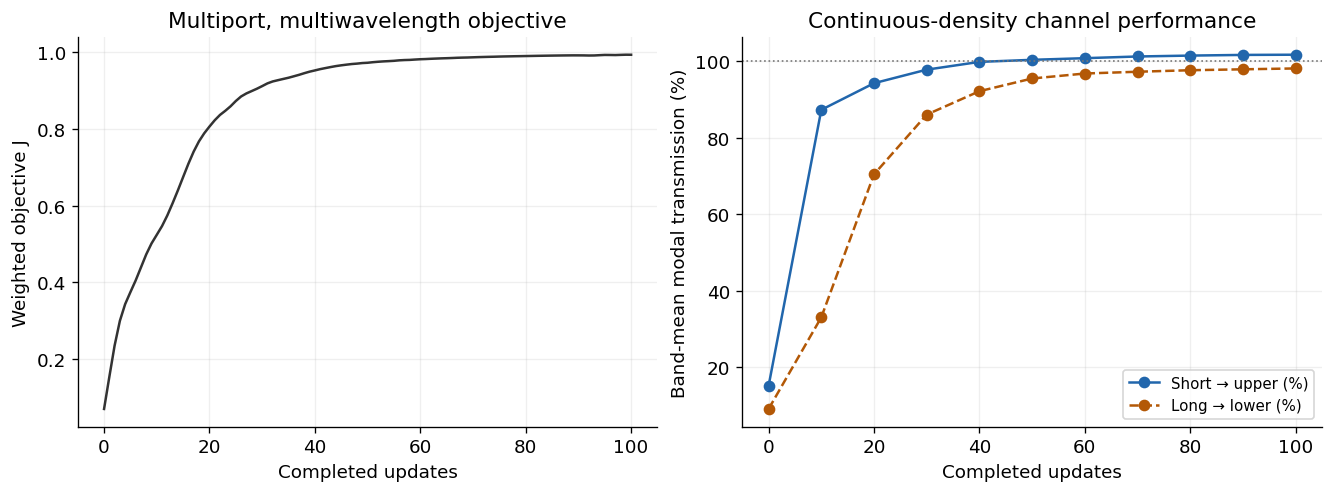

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
axes[0].plot(np.arange(101), np.r_[result.initial_objective, result.state.objective_history], color="#333333")
axes[0].set(xlabel="Completed updates", ylabel="Weighted objective J", title="Multiport, multiwavelength objective")
axes[0].grid(alpha=0.2)
for label, color, style in [("Short → upper (%)", upper_color, "-"), ("Long → lower (%)", lower_color, "--")]:
    axes[1].plot(history["Step"], history[label], color=color, linestyle=style, marker="o", label=label)
axes[1].axhline(100, color="#777777", linestyle=":", linewidth=1)
axes[1].set(xlabel="Completed updates", ylabel="Band-mean modal transmission (%)", title="Continuous-density channel performance")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.2)
plt.show()


**Numerical interpretation.** On this training grid, some continuous-density modal estimates exceed 100%. Values are deliberately not clipped. This flags finite-grid/measurement error, not optical gain. The exported geometry is independently rasterized below, and the reported device performance comes from finer-grid verification rather than the continuous optimization score.

## Checks

### Export geometry and compare it with the density model

Threshold the physical density at 0.5 and convert it to ordinary BeamZ polygons. The exported device is re-rasterized from geometry, so it can differ from the continuous-density Yee material map.


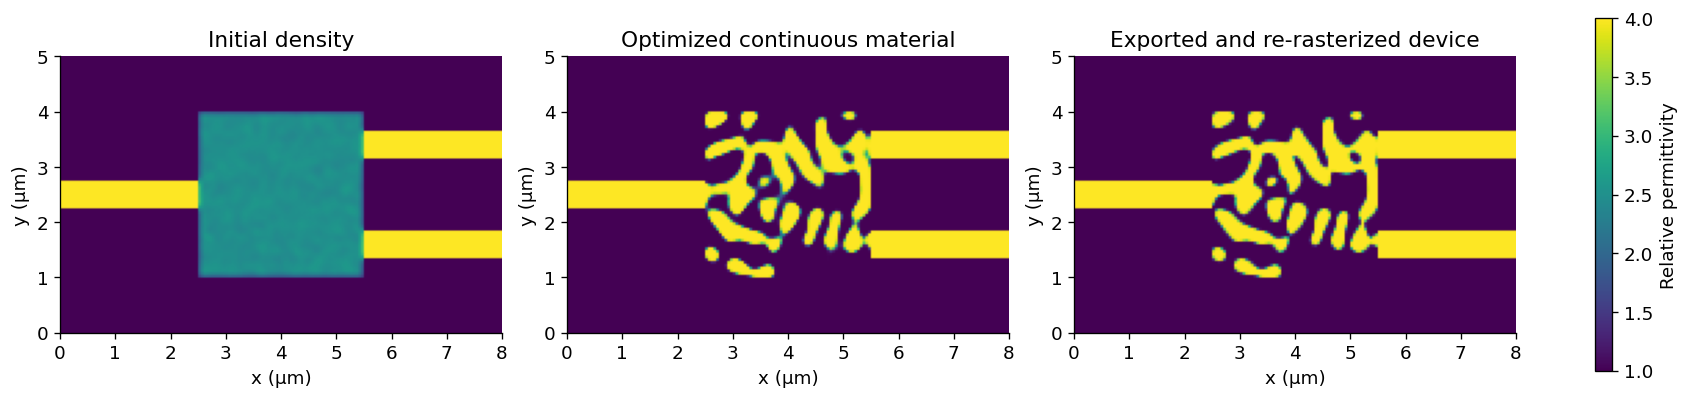

In [7]:
exported_design = problem.export_design(result, threshold=0.5)
initial_material = problem.material_simulation(initial_density, beta=1).compile(backend="jax").grid.permittivity
continuous_material = problem.material_simulation(result.state.density, beta=result.beta).compile(backend="jax").grid.permittivity
exported_material = simulation.updated_copy(design=exported_design).compile(backend="jax").grid.permittivity
fig, axes = plt.subplots(1, 3, figsize=(14, 4), layout="constrained")
for ax, material, title in zip(axes, [initial_material, continuous_material, exported_material],
                              ["Initial density", "Optimized continuous material", "Exported and re-rasterized device"]):
    image = ax.imshow(material, origin="lower", extent=(0, 8, 0, 5), cmap="viridis", vmin=1, vmax=4)
    ax.set(xlabel="x (µm)", ylabel="y (µm)", title=title)
fig.colorbar(image, ax=axes, label="Relative permittivity", shrink=0.75)
plt.show()


### Mesh and run-time sensitivity

For each fresh simulation, independently compute upper/lower fundamental-mode powers and input reflection. The table uses the six training wavelengths. Report unwanted-port power relative to the incident power, and channel isolation as $10\log_{10}(T_{\rm desired}/T_{\rm unwanted})$; these are different quantities.


In [8]:
def modal_powers(data):
    incoming_power = abs(data.mode("input").amps.sel(direction="+", mode_index=0).values) ** 2
    powers = {}
    for name in ("upper", "lower", "input"):
        direction = "-" if name == "input" else "+"
        powers[name] = abs(data.mode(name).amps.sel(direction=direction, mode_index=0).values) ** 2 / incoming_power
    return powers

def routing_summary(powers):
    desired = np.r_[powers["upper"][:3], powers["lower"][3:]]
    unwanted = np.r_[powers["lower"][:3], powers["upper"][3:]]
    return {"Short band mean (%)": 100 * desired[:3].mean(),
            "Long band mean (%)": 100 * desired[3:].mean(),
            "Worst desired (%)": 100 * desired.min(),
            "Worst unwanted (%)": 100 * unwanted.max(),
            "Worst reflection (%)": 100 * powers["input"].max(),
            "Worst isolation (dB)": 10 * np.log10(np.min(desired / unwanted))}

verification_rows, verification_spectra = [], []
for spacing, duration in [(50e-9, 220e-15), (50e-9, 320e-15), (40e-9, 320e-15),
                          (25e-9, 320e-15), (25e-9, 400e-15), (20e-9, 320e-15)]:
    verified = simulation.updated_copy(design=exported_design, resolution=spacing, run_time=duration)
    data = verified.run(backend="jax", performance=False)
    powers = modal_powers(data)
    verification_spectra.append(powers)
    verification_rows.append({"Grid (nm)": spacing * 1e9, "Run (fs)": duration * 1e15,
                              **routing_summary(powers)})
verification = pd.DataFrame(verification_rows)
display(verification.round(3))
assert np.isfinite(verification.to_numpy()).all()
assert verification.iloc[-1]["Worst desired (%)"] > 70
assert verification.iloc[-1]["Worst unwanted (%)"] < 5

finest = verification_spectra[-1]
channel_table = pd.DataFrame({"Wavelength (nm)": training_wavelengths * 1e9,
                              "Target port": ["upper"] * 3 + ["lower"] * 3,
                              "Upper (%)": 100 * finest["upper"], "Lower (%)": 100 * finest["lower"],
                              "Reflection (%)": 100 * finest["input"]})
display(channel_table.round(3))


,Grid (nm),Run (fs),Short band mean (%),Long band mean (%),Worst desired (%),Worst unwanted (%),Worst reflection (%),Worst isolation (dB)
0,50.0,220.0,97.010,95.098,94.617,0.850,5.716,20.497
1,50.0,320.0,96.993,95.101,94.669,0.848,5.729,20.506
2,40.0,320.0,94.091,92.676,92.195,0.810,5.537,20.585
3,25.0,320.0,93.186,91.903,91.142,0.812,5.901,20.501
4,25.0,400.0,93.187,91.903,91.142,0.812,5.900,20.501
5,20.0,320.0,92.393,91.261,90.344,0.802,5.876,20.517


,Wavelength (nm),Target port,Upper (%),Lower (%),Reflection (%)
0,1280.0,upper,92.096,0.425,4.318
1,1300.0,upper,93.427,0.531,3.243
2,1320.0,upper,91.657,0.741,3.402
3,1530.0,lower,0.647,91.417,4.053
4,1550.0,lower,0.767,92.023,3.497
5,1570.0,lower,0.802,90.344,5.876


### Verify wavelengths that were not used for training

A separate 25 nm, 400 fs simulation samples the spectrum every 10 nm from 1250 to 1600 nm. Shaded regions mark the requested passbands. Intermediate points within each band were not present in the optimization objective. The spectral interval between the bands has no routing requirement and can reflect strongly.


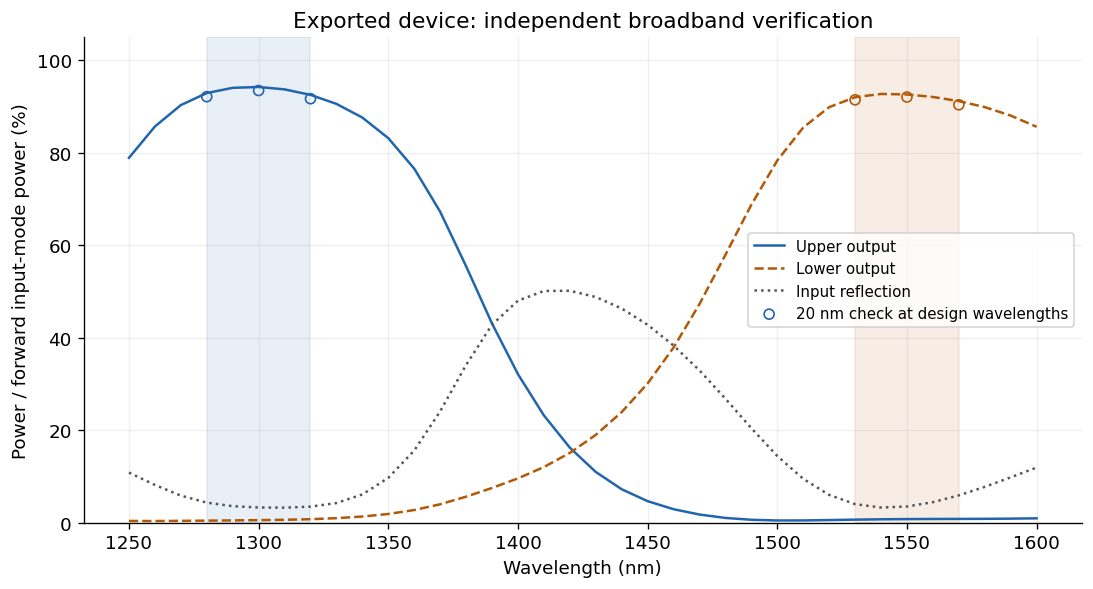

**Measured outcome:** the exported device reaches **90.34% or better** target-port transmission at the six design wavelengths on the 20 nm grid. Unwanted-port power stays below **0.80%** of incident power, with at least **20.52 dB** channel isolation. The independent 25 nm sweep retains at least **91.14%** desired transmission across the sampled passbands.

In [9]:
sweep_wavelengths = np.linspace(1.25, 1.60, 36) * 1e-6
sweep_monitors = [monitor.updated_copy(freqs=LIGHT_SPEED / sweep_wavelengths) for monitor in simulation.monitors]
sweep_simulation = simulation.updated_copy(design=exported_design, resolution=25e-9,
                                          run_time=400e-15, monitors=sweep_monitors)
sweep_results = sweep_simulation.run(backend="jax", performance=False)
sweep = modal_powers(sweep_results)

fig, ax = plt.subplots(figsize=(9, 4.8), layout="constrained")
ax.axvspan(1280, 1320, color=upper_color, alpha=0.1)
ax.axvspan(1530, 1570, color=lower_color, alpha=0.1)
for port, color, style, label in [("upper", upper_color, "-", "Upper output"),
                                  ("lower", lower_color, "--", "Lower output"),
                                  ("input", reflection_color, ":", "Input reflection")]:
    ax.plot(sweep_wavelengths * 1e9, 100 * sweep[port], color=color, linestyle=style, label=label)
ax.scatter(training_wavelengths[:3] * 1e9, 100 * finest["upper"][:3], color=upper_color,
           marker="o", facecolors="none", label="20 nm check at design wavelengths")
ax.scatter(training_wavelengths[3:] * 1e9, 100 * finest["lower"][3:], color=lower_color,
           marker="o", facecolors="none")
ax.set(xlabel="Wavelength (nm)", ylabel="Power / forward input-mode power (%)",
       title="Exported device: independent broadband verification", ylim=(0, 105))
ax.grid(alpha=0.2)
ax.legend(fontsize=9, loc="center right")
plt.show()

short_band = (sweep_wavelengths >= 1.28e-6 - 1e-15) & (sweep_wavelengths <= 1.32e-6 + 1e-15)
long_band = (sweep_wavelengths >= 1.53e-6 - 1e-15) & (sweep_wavelengths <= 1.57e-6 + 1e-15)
dense_desired = np.r_[sweep["upper"][short_band], sweep["lower"][long_band]]
dense_unwanted = np.r_[sweep["lower"][short_band], sweep["upper"][long_band]]
assert dense_desired.min() > 0.7 and dense_unwanted.max() < 0.05
np.savez_compressed(artifact_dir / "wdm_verified_spectrum.npz", wavelength_m=sweep_wavelengths, **sweep)
final_check = verification.iloc[-1]
display(Markdown(f"**Measured outcome:** the exported device reaches **{final_check['Worst desired (%)']:.2f}% or better** target-port transmission at the six design wavelengths on the 20 nm grid. Unwanted-port power stays below **{final_check['Worst unwanted (%)']:.2f}%** of incident power, with at least **{final_check['Worst isolation (dB)']:.2f} dB** channel isolation. The independent 25 nm sweep retains at least **{100 * dense_desired.min():.2f}%** desired transmission across the sampled passbands."))


## Next Steps

This example adds multi-frequency modal objectives, frequency-matched incident normalization, weighted multiport composition, reflection/crosstalk penalties, and per-term spectral diagnostics. It still uses one fixed excitation and one 2D simulation. It does not implement multi-source S-matrix optimization, fabrication-variant batches, hard manufacturing constraints, shape optimization, or a 3D/native-CUDA adjoint.

The mesh checks show sensitivity rather than proving continuum convergence. Before using a physical device, extend the study to lead length, modal aperture, denser spectral sampling, polarization, fabrication variations, and 3D material stacks. The 2D dielectric model here is not the silicon device in the cited paper, and no Tidy3D simulation was run as a numerical benchmark.

For API details, see [the inverse-design guide](../../docs/inverse-design.md). For simpler gradient checks and exact restart comparisons, see [the companion notebook](topology_gradient_checks.ipynb).
